# Diabetes Progression EDA & Regression Model
**Dataset:** Diabetes dataset (scikit-learn)  
**Goal:** Explore features related to diabetes progression and build baseline regression models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
data = load_diabetes(as_frame=True)
df = data.frame.copy()  # features + target
df['target'] = data.target  # disease progression measure

df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values per column:\n", df.isna().sum())

df.describe().T


Shape: (442, 11)

Columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

Missing values per column:
 age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


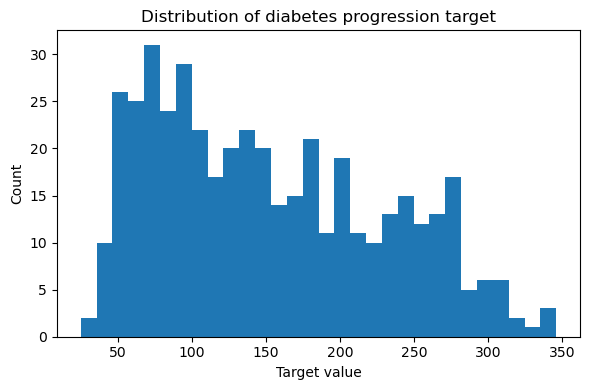

In [4]:
plt.figure(figsize=(6,4))
plt.hist(df['target'], bins=30)
plt.title("Distribution of diabetes progression target")
plt.xlabel("Target value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Top positive correlations with target:



bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


Top negative correlations with target:



bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64

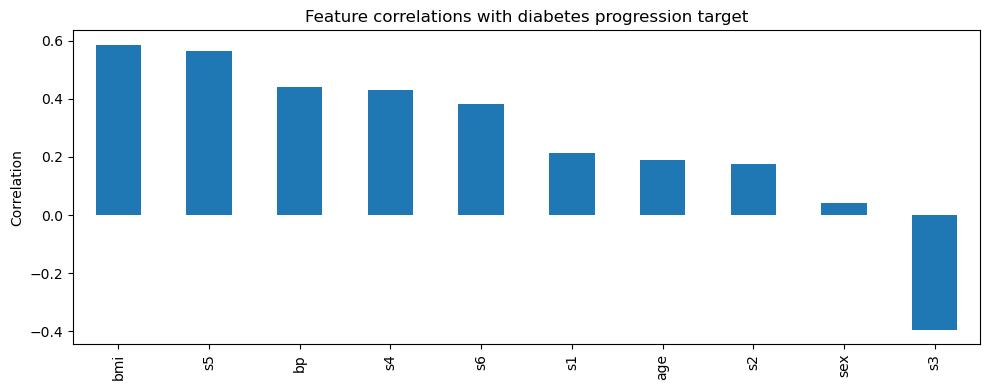

In [5]:
corr_with_target = df.corr(numeric_only=True)['target'].drop('target').sort_values(ascending=False)

print("Top positive correlations with target:\n")
display(corr_with_target.head(10))

print("\nTop negative correlations with target:\n")
display(corr_with_target.tail(10))

plt.figure(figsize=(10,4))
corr_with_target.plot(kind='bar')
plt.title("Feature correlations with diabetes progression target")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()


In [6]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((353, 10), (89, 10))

In [7]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MSE:", mse_lr)
print("R²:", r2_lr)


Linear Regression
MSE: 2900.193628493482
R²: 0.45260276297191937


In [8]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("MSE:", mse_ridge)
print("R²:", r2_ridge)


Ridge Regression
MSE: 3077.41593882723
R²: 0.41915292635986545


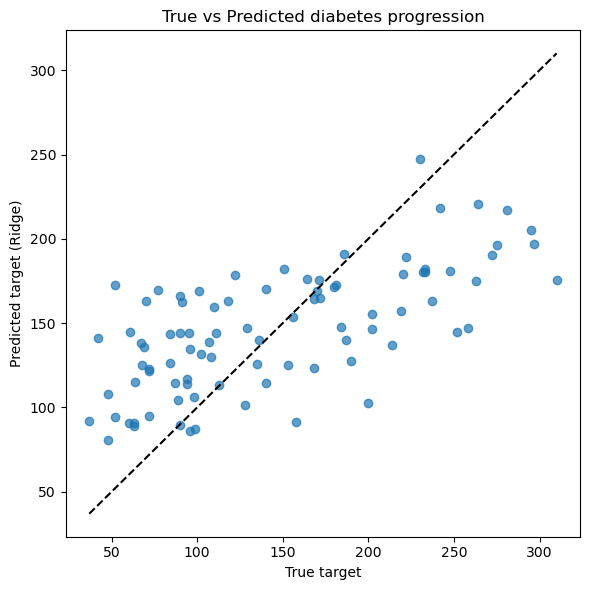

In [9]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("True target")
plt.ylabel("Predicted target (Ridge)")
plt.title("True vs Predicted diabetes progression")
plt.tight_layout()
plt.show()


## Conclusions

- Explored the diabetes dataset from scikit-learn with numeric clinical features and a continuous disease progression target.
- Identified the most correlated features with the progression target.
- Built baseline Linear Regression and Ridge Regression models and evaluated them using MSE and R² on a held-out test set.
- Next steps: feature scaling, more regularization tuning, and trying non-linear models such as RandomForestRegressor or GradientBoostingRegressor.
